In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('../data/raw/results.csv')

In [4]:
data.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [5]:
# The result is relative to team 1: 1 -> win, 2-> lose and 0 -> draw

In [6]:
data[data['date'] > '1930']

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
1426,1930-01-01,Spain,Czechoslovakia,1.0,0.0,Friendly,Barcelona,Spain,False
1427,1930-01-12,Portugal,Czechoslovakia,1.0,0.0,Friendly,Lisbon,Portugal,False
1428,1930-01-26,Greece,Yugoslavia,2.0,1.0,Balkan Cup,Athens,Greece,False
1429,1930-02-01,Northern Ireland,Wales,7.0,0.0,British Home Championship,Belfast,Northern Ireland,False
1430,1930-02-09,Italy,Switzerland,4.0,2.0,Friendly,Rome,Italy,False
...,...,...,...,...,...,...,...,...,...
49515,2026-07-11,Argentina,Switzerland,3.0,1.0,FIFA World Cup,Kansas City,United States,True
49516,2026-07-14,France,Spain,0.0,2.0,FIFA World Cup,Arlington,United States,True
49517,2026-07-15,England,Argentina,1.0,2.0,FIFA World Cup,Atlanta,United States,True
49518,2026-07-18,France,England,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True


<Axes: ylabel='tournament'>

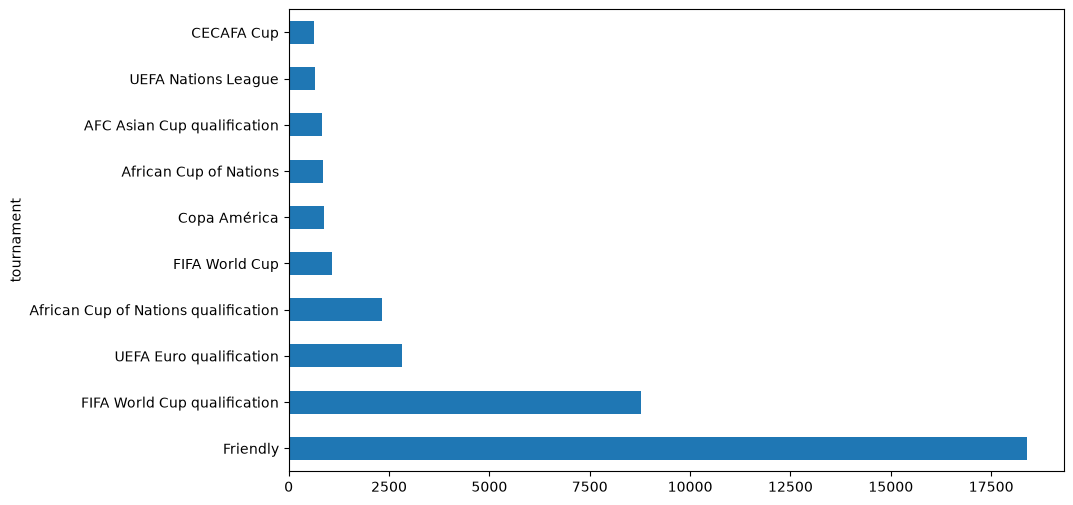

In [7]:
data.groupby('tournament').size().sort_values(ascending=False).head(10).plot(kind='barh', figsize=(10, 6))

In [8]:
print(data['tournament'].value_counts())

tournament
Friendly                                18387
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                           1068
                                        ...  
Copa Confraternidad                         1
Benedikt Fontana Cup                        1
ConIFA Challenger Cup                       1
CONIFA World Cup qualification              1
South Asian Super Cup                       1
Name: count, Length: 201, dtype: int64


In [9]:
copa_rows = data[data['tournament'].str.contains('Conca', case=False, na=False)]

In [10]:
copa_rows

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
5732,1963-03-23,Guatemala,Panama,2.0,2.0,CONCACAF Championship,San Salvador,El Salvador,True
5733,1963-03-23,El Salvador,Nicaragua,6.0,1.0,CONCACAF Championship,San Salvador,El Salvador,False
5738,1963-03-24,Costa Rica,Jamaica,6.0,0.0,CONCACAF Championship,Santa Ana,El Salvador,True
5739,1963-03-24,Mexico,Curaçao,1.0,2.0,CONCACAF Championship,Santa Ana,El Salvador,True
5741,1963-03-25,Honduras,Nicaragua,1.0,0.0,CONCACAF Championship,San Salvador,El Salvador,True
...,...,...,...,...,...,...,...,...,...
49203,2026-03-29,Bonaire,Saint Martin,0.0,3.0,CONCACAF Series,Rincon,Bonaire,False
49204,2026-03-29,British Virgin Islands,Anguilla,4.0,0.0,CONCACAF Series,George Town,Cayman Islands,True
49205,2026-03-29,Cayman Islands,Bahamas,1.0,0.0,CONCACAF Series,George Town,Cayman Islands,False
49217,2026-03-30,Guyana,Belize,3.0,1.0,CONCACAF Series,Santiago de los Caballeros,Dominican Republic,True


In [11]:
data['tournament'] = data['tournament'].replace({
    'African Cup of Nations': 'AFCON',
    'Copa América': 'COPA',
    'UEFA Nations League': 'UEFA',
    'FIFA World Cup': 'FWC',
    'AFC Asian Cup': 'AFC',
    'UEFA Euro': 'EURO',
    'CONCACAF Championship': 'CONCACAF'
})

In [12]:
major_tournaments = [
    'AFCON', 'COPA', 'UEFA', 'FWC', 'AFC', 'EURO', 'CONCACAF'
]

In [13]:
major_data = data[data['tournament'].isin(major_tournaments)]

In [14]:
major_data

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
479,1916-07-02,Chile,Uruguay,0.0,4.0,COPA,Buenos Aires,Argentina,True
481,1916-07-06,Argentina,Chile,6.0,1.0,COPA,Buenos Aires,Argentina,False
482,1916-07-08,Brazil,Chile,1.0,1.0,COPA,Buenos Aires,Argentina,True
483,1916-07-10,Argentina,Brazil,1.0,1.0,COPA,Buenos Aires,Argentina,False
485,1916-07-12,Brazil,Uruguay,1.0,2.0,COPA,Buenos Aires,Argentina,True
...,...,...,...,...,...,...,...,...,...
49515,2026-07-11,Argentina,Switzerland,3.0,1.0,FWC,Kansas City,United States,True
49516,2026-07-14,France,Spain,0.0,2.0,FWC,Arlington,United States,True
49517,2026-07-15,England,Argentina,1.0,2.0,FWC,Atlanta,United States,True
49518,2026-07-18,France,England,NaN,NaN,FWC,Miami Gardens,United States,True


In [15]:
major_data['year'] = pd.to_datetime(major_data['date']).dt.year
major_data['month'] = pd.to_datetime(major_data['date']).dt.month
major_data['day'] = pd.to_datetime(major_data['date']).dt.day

<Axes: ylabel='year'>

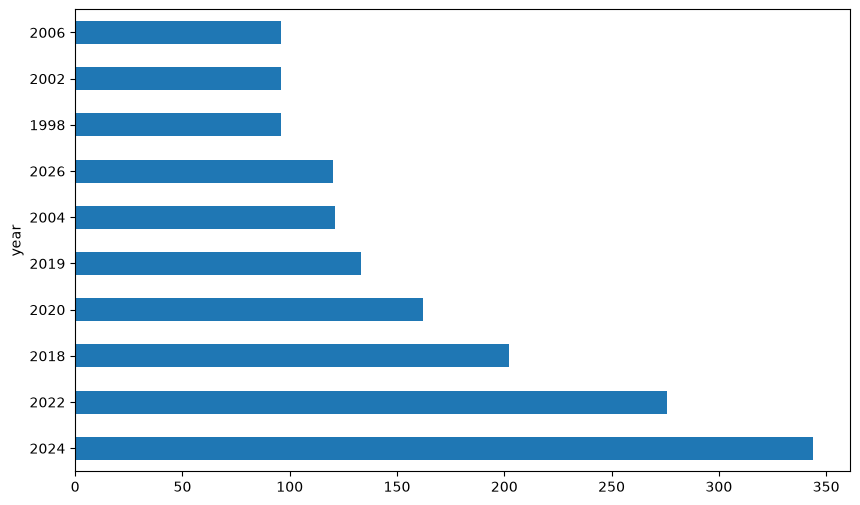

In [16]:
major_data.groupby('year').size().sort_values(ascending=False).head(10).plot(kind='barh', figsize=(10, 6))

In [17]:
major_data[major_data['year'].isin([2025, 2026])]

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,month,day
48126,2025-03-20,Croatia,France,2.0,0.0,UEFA,Split,Croatia,False,2025,3,20
48127,2025-03-20,Denmark,Portugal,1.0,0.0,UEFA,Copenhagen,Denmark,False,2025,3,20
48128,2025-03-20,Italy,Germany,1.0,2.0,UEFA,Milan,Italy,False,2025,3,20
48129,2025-03-20,Netherlands,Spain,2.0,2.0,UEFA,Rotterdam,Netherlands,False,2025,3,20
48130,2025-03-20,Austria,Serbia,1.0,1.0,UEFA,Vienna,Austria,False,2025,3,20
...,...,...,...,...,...,...,...,...,...,...,...,...
49515,2026-07-11,Argentina,Switzerland,3.0,1.0,FWC,Kansas City,United States,True,2026,7,11
49516,2026-07-14,France,Spain,0.0,2.0,FWC,Arlington,United States,True,2026,7,14
49517,2026-07-15,England,Argentina,1.0,2.0,FWC,Atlanta,United States,True,2026,7,15
49518,2026-07-18,France,England,NaN,NaN,FWC,Miami Gardens,United States,True,2026,7,18


In [18]:
major_data.isna().sum()

date          0
home_team     0
away_team     0
home_score    2
away_score    2
tournament    0
city          0
country       0
neutral       0
year          0
month         0
day           0
dtype: int64

In [ ]:
major_data = major_data.dropna()

In [22]:
test_data = major_data[major_data['date'] > '2024-06-20']

In [ ]:
test_data.to_csv("../data/test/test.csv")

In [24]:
train_data = major_data[major_data['date'] <= '2024-06-20']

In [25]:
train_data.to_csv("../data/train/train.csv")